
# Part B — 10b Forecast Feature Improvement

## Goal

Notebook 10 showed an important result:

> With the first feature set, **historical climatology beat the ML models on walk-forward MAE**.

That means the next step is **not** to force a more complex model.  
The next step is to test whether additional large-scale climate signals add genuine out-of-sample forecast skill.

This notebook adds four pre-winter climate indices:

- **AO** — Arctic Oscillation
- **NAO** — North Atlantic Oscillation
- **PNA** — Pacific–North American pattern
- **PDO** — Pacific Decadal Oscillation

We test them **one at a time** and then together.

## Leakage rule

The forecast is assumed to be issued around **November 1**.

To avoid using information that would not yet be available, the new teleconnection features use the **July–August–September (JAS) mean** from the calendar year before the snow season ends.

Example:

- Snow season ending in `2026`
- Forecast issued around November 1, 2025
- Use JAS 2025 AO / NAO / PNA / PDO

We deliberately do **not** use winter AO/NAO/PNA values, because those occur after the forecast is issued.

## Evaluation

Every feature set is tested with the same:

- expanding-window walk-forward validation,
- ElasticNet model,
- common test winters,
- MAE and RMSE,
- recent-period diagnostics.

This isolates whether a new climate feature improves forecasting rather than changing several things at once.


In [1]:

from pathlib import Path
from io import StringIO
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_INDEX_DIR = PROJECT_ROOT / "data" / "raw" / "climate_indices"
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"

for directory in [PROCESSED_DIR, RAW_INDEX_DIR, FIGURES_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_DATA_PATH = PROCESSED_DIR / "forecast_modeling_dataset.csv"

if not MODEL_DATA_PATH.exists():
    raise FileNotFoundError(
        "forecast_modeling_dataset.csv was not found. "
        "Run 10_forecast_modeling.ipynb through the save-output section first."
    )

base = pd.read_csv(MODEL_DATA_PATH)
base = base.sort_values("season_year").reset_index(drop=True)

print("Base modeling rows:", len(base))
print("Season range:", base["season_year"].min(), "→", base["season_year"].max())
display(base.head())


Base modeling rows: 70
Season range: 1951 → 2026


,season_year,snowfall_cm,valid_days,missing_days,measurable_snow_days,expected_days,coverage_pct,usable_90pct,full_calendar_window,usable,winter_coverage_pct,usable_strict,snowfall_clean_cm,snow_lag1_cm,snow_roll5_mean_cm,snow_roll10_mean_cm,snow_roll10_std_cm,previous_season_usable,oni_jas,oni_phase_threshold,sep_oct_mean_temp_c,sep_oct_total_precip_mm,sep_oct_temp_coverage_pct,sep_oct_precip_coverage_pct,autumn_features_usable,year_index
0,1951,111.8,365,0,40,365,100.0,True,True,True,100.0,True,111.8,196.4,136.22,141.04,35.388077,True,-0.57,cool_threshold,12.640984,100.0,100.0,100.0,True,12.0
1,1952,184.8,366,0,43,366,100.0,True,True,True,100.0,True,184.8,111.8,140.68,135.82,35.474836,True,0.90,warm_threshold,12.634426,102.3,100.0,100.0,True,13.0
2,1953,53.9,365,0,23,365,100.0,True,True,True,100.0,True,53.9,184.8,148.28,144.61,35.649231,True,-0.20,neutral_threshold,11.896721,77.4,100.0,100.0,True,14.0
3,1954,124.7,365,0,38,365,100.0,True,True,True,100.0,True,124.7,53.9,134.68,131.76,42.929922,True,0.68,warm_threshold,13.195082,92.5,100.0,100.0,True,15.0
4,1955,109.3,365,0,44,365,100.0,True,True,True,100.0,True,109.3,124.7,134.32,131.86,42.910222,True,-0.83,cool_threshold,13.193443,294.6,100.0,100.0,True,16.0



## 1. Official climate-index sources

We use machine-readable NOAA sources:

- **AO** — NOAA Climate Prediction Center monthly AO index
- **NAO** — NOAA Climate Prediction Center monthly NAO index
- **PNA** — NOAA Climate Prediction Center monthly PNA index
- **PDO** — NOAA Physical Sciences Laboratory monthly PDO series

The CPC AO/NAO/PNA files are whitespace tables with:

```text
year  month  value
```

The PSL PDO file uses PSL's standard year × 12-month format.

Raw downloads are cached locally so the notebook does not need to redownload them every run.


In [2]:

INDEX_URLS = {
    "ao": (
        "https://www.cpc.ncep.noaa.gov/products/precip/CWlink/"
        "daily_ao_index/monthly.ao.index.b50.current.ascii"
    ),
    "nao": (
        "https://www.cpc.ncep.noaa.gov/products/precip/CWlink/"
        "pna/norm.nao.monthly.b5001.current.ascii"
    ),
    "pna": (
        "https://www.cpc.ncep.noaa.gov/products/precip/CWlink/"
        "pna/norm.pna.monthly.b5001.current.ascii"
    ),
    "pdo": "https://psl.noaa.gov/pdo/data/pdo.timeseries.sstens.data",
}

INDEX_URLS


{'ao': 'https://www.cpc.ncep.noaa.gov/products/precip/CWlink/daily_ao_index/monthly.ao.index.b50.current.ascii',
 'nao': 'https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii',
 'pna': 'https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.pna.monthly.b5001.current.ascii',
 'pdo': 'https://psl.noaa.gov/pdo/data/pdo.timeseries.sstens.data'}

In [3]:

def get_text(url, cache_name, force_refresh=False):
    cache_path = RAW_INDEX_DIR / cache_name

    if cache_path.exists() and not force_refresh:
        return cache_path.read_text(encoding="utf-8", errors="ignore")

    headers = {
        "User-Agent": "Mozilla/5.0 climate-research-notebook"
    }

    response = requests.get(
        url,
        timeout=60,
        headers=headers
    )
    response.raise_for_status()

    text = response.text
    cache_path.write_text(
        text,
        encoding="utf-8"
    )

    return text


## 2. Parse AO, NAO, and PNA

In [4]:

def read_cpc_three_column(url, name, force_refresh=False):
    text = get_text(
        url,
        f"{name}_monthly.txt",
        force_refresh=force_refresh
    )

    df = pd.read_csv(
        StringIO(text),
        sep=r"\s+",
        header=None,
        names=["year", "month", name],
        usecols=[0, 1, 2],
    )

    for col in ["year", "month", name]:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df = df.dropna(
        subset=["year", "month", name]
    ).copy()

    df["year"] = df["year"].astype(int)
    df["month"] = df["month"].astype(int)

    # Climate-index values are ordinarily small standardized numbers.
    # Treat common large-magnitude missing-value sentinels as missing.
    df.loc[df[name].abs() >= 90, name] = np.nan

    df["date"] = pd.to_datetime(
        dict(
            year=df["year"],
            month=df["month"],
            day=1
        ),
        errors="coerce"
    )

    return (
        df.dropna(subset=["date"])
          .sort_values("date")
          .reset_index(drop=True)
    )


ao_monthly = read_cpc_three_column(
    INDEX_URLS["ao"],
    "ao"
)

nao_monthly = read_cpc_three_column(
    INDEX_URLS["nao"],
    "nao"
)

pna_monthly = read_cpc_three_column(
    INDEX_URLS["pna"],
    "pna"
)

print(
    "AO:",
    ao_monthly["date"].min(),
    "→",
    ao_monthly["date"].max()
)
print(
    "NAO:",
    nao_monthly["date"].min(),
    "→",
    nao_monthly["date"].max()
)
print(
    "PNA:",
    pna_monthly["date"].min(),
    "→",
    pna_monthly["date"].max()
)

display(ao_monthly.tail())
display(nao_monthly.tail())
display(pna_monthly.tail())


AO: 1950-01-01 00:00:00 → 2026-08-01 00:00:00
NAO: 1950-01-01 00:00:00 → 2026-08-01 00:00:00
PNA: 1950-01-01 00:00:00 → 2026-08-01 00:00:00


,year,month,ao,date
915,2026,4,0.2541,2026-04-01
916,2026,5,0.5448,2026-05-01
917,2026,6,0.6601,2026-06-01
918,2026,7,0.3035,2026-07-01
919,2026,8,-0.0560,2026-08-01


,year,month,nao,date
915,2026,4,1.3943,2026-04-01
916,2026,5,-0.7418,2026-05-01
917,2026,6,0.1014,2026-06-01
918,2026,7,-0.3134,2026-07-01
919,2026,8,-1.9164,2026-08-01


,year,month,pna,date
915,2026,4,-1.2577,2026-04-01
916,2026,5,-1.2693,2026-05-01
917,2026,6,-0.5005,2026-06-01
918,2026,7,0.6149,2026-07-01
919,2026,8,-0.0797,2026-08-01


## 3. Parse PDO

In [5]:

def read_psl_year12(url, name, force_refresh=False):
    text = get_text(
        url,
        f"{name}_monthly.txt",
        force_refresh=force_refresh
    )

    records = []

    for line in text.splitlines():
        parts = line.split()

        # Data rows in PSL standard format:
        # year Jan Feb Mar ... Dec
        if len(parts) != 13:
            continue

        try:
            year = int(float(parts[0]))
        except ValueError:
            continue

        if not (1800 <= year <= 2200):
            continue

        for month, raw_value in enumerate(parts[1:], start=1):
            try:
                value = float(raw_value)
            except ValueError:
                value = np.nan

            # PSL files commonly use large values such as -99 or -999
            # as missing-data sentinels.
            if pd.notna(value) and abs(value) >= 90:
                value = np.nan

            records.append({
                "year": year,
                "month": month,
                name: value,
            })

    df = pd.DataFrame(records)

    if df.empty:
        raise ValueError(
            f"Could not parse monthly {name.upper()} data."
        )

    df["date"] = pd.to_datetime(
        dict(
            year=df["year"],
            month=df["month"],
            day=1
        ),
        errors="coerce"
    )

    return (
        df.dropna(subset=["date"])
          .sort_values("date")
          .reset_index(drop=True)
    )


pdo_monthly = read_psl_year12(
    INDEX_URLS["pdo"],
    "pdo"
)

print(
    "PDO:",
    pdo_monthly["date"].min(),
    "→",
    pdo_monthly["date"].max()
)

display(pdo_monthly.tail(15))


PDO: 1870-01-01 00:00:00 → 2026-12-01 00:00:00


,year,month,pdo,date
1869,2025,10,-2.393,2025-10-01
1870,2025,11,-1.797,2025-11-01
1871,2025,12,-1.260,2025-12-01
1872,2026,1,-1.336,2026-01-01
1873,2026,2,-0.898,2026-02-01
1874,2026,3,-1.244,2026-03-01
1875,2026,4,-1.211,2026-04-01
1876,2026,5,-1.451,2026-05-01
1877,2026,6,-1.608,2026-06-01
1878,2026,7,-1.598,2026-07-01


## 4. Convert monthly indices into leakage-safe JAS features

In [6]:

def make_jas_feature(df, value_col):
    jas = df[
        df["month"].isin([7, 8, 9])
    ].copy()

    out = (
        jas.groupby("year")
        .agg(
            value=(value_col, "mean"),
            valid_months=(value_col, "count")
        )
        .reset_index()
    )

    # Require all three JAS months.
    out.loc[
        out["valid_months"] != 3,
        "value"
    ] = np.nan

    out["season_year"] = out["year"] + 1

    return out[
        ["season_year", "value", "valid_months"]
    ].rename(
        columns={
            "value": f"{value_col}_jas",
            "valid_months": f"{value_col}_jas_valid_months"
        }
    )


ao_jas = make_jas_feature(
    ao_monthly,
    "ao"
)

nao_jas = make_jas_feature(
    nao_monthly,
    "nao"
)

pna_jas = make_jas_feature(
    pna_monthly,
    "pna"
)

pdo_jas = make_jas_feature(
    pdo_monthly,
    "pdo"
)

display(ao_jas.tail())
display(nao_jas.tail())
display(pna_jas.tail())
display(pdo_jas.tail())


,season_year,ao_jas,ao_jas_valid_months
72,2023,-0.266767,3
73,2024,-0.146233,3
74,2025,0.415567,3
75,2026,0.194733,3
76,2027,NaN,2


,season_year,nao_jas,nao_jas_valid_months
72,2023,-0.078067,3
73,2024,-1.259800,3
74,2025,0.219900,3
75,2026,-0.020900,3
76,2027,NaN,2


,season_year,pna_jas,pna_jas_valid_months
72,2023,1.179667,3
73,2024,0.883467,3
74,2025,0.976833,3
75,2026,0.395533,3
76,2027,NaN,2


,season_year,pdo_jas,pdo_jas_valid_months
152,2023,-2.084667,3
153,2024,-2.374333,3
154,2025,-2.441333,3
155,2026,-2.950333,3
156,2027,NaN,1


## 5. Merge new climate features with the existing modeling table

In [7]:

enhanced = (
    base
    .merge(ao_jas, on="season_year", how="left")
    .merge(nao_jas, on="season_year", how="left")
    .merge(pna_jas, on="season_year", how="left")
    .merge(pdo_jas, on="season_year", how="left")
    .sort_values("season_year")
    .reset_index(drop=True)
)

NEW_FEATURES = [
    "ao_jas",
    "nao_jas",
    "pna_jas",
    "pdo_jas",
]

print("Missing new features:")
display(
    enhanced[NEW_FEATURES]
    .isna()
    .sum()
    .to_frame("missing")
)

display(
    enhanced[
        ["season_year", "snowfall_cm"] + NEW_FEATURES
    ].tail(15)
)


Missing new features:


,missing
ao_jas,0
nao_jas,0
pna_jas,0
pdo_jas,0


,season_year,snowfall_cm,ao_jas,nao_jas,pna_jas,pdo_jas
55,2009,152.7,-0.295667,-0.472467,0.646467,-1.422000
56,2010,52.4,-0.178367,-0.279267,1.052067,0.007667
57,2011,128.8,-0.181967,-0.814167,1.277767,-1.743000
58,2012,42.8,-0.289833,-0.774567,0.215700,-2.214000
59,2013,106.7,0.318000,-0.963600,-0.251700,-2.059333
60,2015,99.3,-0.252833,0.036733,1.115400,0.245667
61,2016,65.9,-0.653800,-1.529300,-0.026000,1.087000
62,2017,85.2,0.446067,-0.931533,0.108467,-0.038333
63,2018,109.7,0.097267,-0.151600,0.588367,-0.312333
64,2019,138.5,0.677467,1.676633,0.778867,-0.290333



## 6. Use a common comparison sample

To compare feature sets fairly, every model must be evaluated on the **same winters**.

If one climate index is missing for a season, that season is removed from all comparisons in this notebook.


In [8]:

BASE_FEATURES = [
    "oni_jas",
    "sep_oct_mean_temp_c",
    "sep_oct_total_precip_mm",
    "snow_lag1_cm",
    "snow_roll5_mean_cm",
    "snow_roll10_mean_cm",
    "snow_roll10_std_cm",
    "year_index",
]

required_cols = (
    ["season_year", "snowfall_cm"]
    + BASE_FEATURES
    + NEW_FEATURES
)

analysis_data = (
    enhanced
    .dropna(subset=required_cols)
    .sort_values("season_year")
    .reset_index(drop=True)
)

print("Common comparison rows:", len(analysis_data))
print(
    "Common season range:",
    analysis_data["season_year"].min(),
    "→",
    analysis_data["season_year"].max()
)

assert analysis_data["season_year"].is_monotonic_increasing
assert analysis_data["season_year"].is_unique
assert analysis_data[required_cols].notna().all().all()

print("Common-sample checks passed.")


Common comparison rows: 70
Common season range: 1951 → 2026
Common-sample checks passed.


## 7. Descriptive relationships

In [9]:

corr_features = [
    "snowfall_cm",
    "oni_jas",
    "ao_jas",
    "nao_jas",
    "pna_jas",
    "pdo_jas",
    "sep_oct_mean_temp_c",
    "sep_oct_total_precip_mm",
]

corr = (
    analysis_data[corr_features]
    .corr(numeric_only=True)["snowfall_cm"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_snowfall")
)

display(corr)


,correlation_with_snowfall
snowfall_cm,1.000000
nao_jas,0.278200
sep_oct_mean_temp_c,0.072384
pna_jas,0.040001
ao_jas,0.038479
pdo_jas,-0.136021
sep_oct_total_precip_mm,-0.216294
oni_jas,-0.249367



These correlations are only exploratory.

A climate index is useful for this project only if it improves **future-like walk-forward forecasts**. A strong in-sample correlation is not enough.


## 8. Define common walk-forward evaluation

In [10]:

MIN_TRAIN_SIZE = 20

if len(analysis_data) <= MIN_TRAIN_SIZE:
    raise ValueError(
        f"Only {len(analysis_data)} common rows are available."
    )

FIRST_TEST_SEASON = int(
    analysis_data.iloc[MIN_TRAIN_SIZE]["season_year"]
)
LAST_TEST_SEASON = int(
    analysis_data.iloc[-1]["season_year"]
)

print("Training minimum:", MIN_TRAIN_SIZE)
print("First test season:", FIRST_TEST_SEASON)
print("Last test season:", LAST_TEST_SEASON)
print(
    "Out-of-sample winters:",
    len(analysis_data) - MIN_TRAIN_SIZE
)


Training minimum: 20
First test season: 1971
Last test season: 2026
Out-of-sample winters: 50


In [11]:

def make_elasticnet(n_train):
    n_splits = min(
        5,
        max(2, n_train // 6)
    )

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            ElasticNetCV(
                l1_ratio=[
                    0.1, 0.3, 0.5,
                    0.7, 0.9, 1.0
                ],
                alphas=np.logspace(-3, 2, 60),
                cv=TimeSeriesSplit(
                    n_splits=n_splits
                ),
                max_iter=20000,
            )
        )
    ])


def rmse(actual, predicted):
    return np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )


## 9. Pre-specified feature sets

In [12]:

FEATURE_SETS = {
    "Base": BASE_FEATURES,

    "Base + AO": (
        BASE_FEATURES
        + ["ao_jas"]
    ),

    "Base + NAO": (
        BASE_FEATURES
        + ["nao_jas"]
    ),

    "Base + PNA": (
        BASE_FEATURES
        + ["pna_jas"]
    ),

    "Base + PDO": (
        BASE_FEATURES
        + ["pdo_jas"]
    ),

    "Base + AO + NAO + PNA + PDO": (
        BASE_FEATURES
        + [
            "ao_jas",
            "nao_jas",
            "pna_jas",
            "pdo_jas",
        ]
    ),
}

for name, cols in FEATURE_SETS.items():
    print(name, "→", len(cols), "features")


Base → 8 features
Base + AO → 9 features
Base + NAO → 9 features
Base + PNA → 9 features
Base + PDO → 9 features
Base + AO + NAO + PNA + PDO → 12 features



This is a **pre-specified screening experiment**.

We are not trying hundreds of arbitrary combinations and then reporting only the best one. With a small dataset, that would create a large data-snooping risk.


## 10. Walk-forward feature screening

In [13]:

records = []

for test_idx in range(
    MIN_TRAIN_SIZE,
    len(analysis_data)
):
    train = analysis_data.iloc[:test_idx]
    test = analysis_data.iloc[[test_idx]]

    season_year = int(
        test["season_year"].iloc[0]
    )
    actual = float(
        test["snowfall_cm"].iloc[0]
    )

    # Same climatology baseline for every feature experiment.
    climatology_pred = float(
        train["snowfall_cm"].mean()
    )

    records.append({
        "season_year": season_year,
        "feature_set": "Historical Climatology",
        "actual_cm": actual,
        "predicted_cm": climatology_pred,
    })

    for set_name, feature_cols in FEATURE_SETS.items():
        model = make_elasticnet(
            len(train)
        )

        model.fit(
            train[feature_cols],
            train["snowfall_cm"]
        )

        pred = float(
            model.predict(
                test[feature_cols]
            )[0]
        )

        records.append({
            "season_year": season_year,
            "feature_set": set_name,
            "actual_cm": actual,
            "predicted_cm": pred,
        })

screen_predictions = pd.DataFrame(records)

screen_predictions["error_cm"] = (
    screen_predictions["predicted_cm"]
    - screen_predictions["actual_cm"]
)

screen_predictions["abs_error_cm"] = (
    screen_predictions["error_cm"].abs()
)

print("Prediction rows:", len(screen_predictions))
display(screen_predictions.head(14))


Prediction rows: 350


,season_year,feature_set,actual_cm,predicted_cm,error_cm,abs_error_cm
0,1971,Historical Climatology,171.7,130.045000,-41.655000,41.655000
1,1971,Base,171.7,129.662206,-42.037794,42.037794
2,1971,Base + AO,171.7,129.954322,-41.745678,41.745678
3,1971,Base + NAO,171.7,129.632280,-42.067720,42.067720
4,1971,Base + PNA,171.7,129.110270,-42.589730,42.589730
5,1971,Base + PDO,171.7,129.823898,-41.876102,41.876102
6,1971,Base + AO + NAO + PNA + PDO,171.7,130.008151,-41.691849,41.691849
7,1972,Historical Climatology,188.9,132.028571,-56.871429,56.871429
8,1972,Base,188.9,132.028571,-56.871429,56.871429
9,1972,Base + AO,188.9,132.028571,-56.871429,56.871429


## 11. Compare feature sets

In [14]:

comparison = (
    screen_predictions
    .groupby("feature_set")
    .apply(
        lambda g: pd.Series({
            "n_forecasts": len(g),
            "MAE_cm": mean_absolute_error(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "RMSE_cm": rmse(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "Bias_cm": g["error_cm"].mean(),
        }),
        include_groups=False
    )
    .reset_index()
)

clim_mae = float(
    comparison.loc[
        comparison["feature_set"]
        == "Historical Climatology",
        "MAE_cm"
    ].iloc[0]
)

base_mae = float(
    comparison.loc[
        comparison["feature_set"]
        == "Base",
        "MAE_cm"
    ].iloc[0]
)

comparison["skill_vs_climatology_pct"] = (
    1 - comparison["MAE_cm"] / clim_mae
) * 100

comparison["mae_improvement_vs_base_cm"] = (
    base_mae - comparison["MAE_cm"]
)

comparison["mae_improvement_vs_base_pct"] = (
    1 - comparison["MAE_cm"] / base_mae
) * 100

comparison = comparison.sort_values(
    ["MAE_cm", "RMSE_cm"]
).reset_index(drop=True)

display(
    comparison.style.format({
        "n_forecasts": "{:.0f}",
        "MAE_cm": "{:.2f}",
        "RMSE_cm": "{:.2f}",
        "Bias_cm": "{:+.2f}",
        "skill_vs_climatology_pct": "{:+.1f}%",
        "mae_improvement_vs_base_cm": "{:+.2f}",
        "mae_improvement_vs_base_pct": "{:+.1f}%"
    })
)


,feature_set,n_forecasts,MAE_cm,RMSE_cm,Bias_cm,skill_vs_climatology_pct,mae_improvement_vs_base_cm,mae_improvement_vs_base_pct
0,Base + NAO,50,31.30,38.05,+8.82,+0.8%,+0.33,+1.0%
1,Historical Climatology,50,31.56,37.87,+9.92,+0.0%,+0.08,+0.2%
2,Base + PDO,50,31.60,37.93,+8.92,-0.1%,+0.04,+0.1%
3,Base,50,31.64,37.97,+8.84,-0.2%,+0.00,+0.0%
4,Base + PNA,50,31.67,37.95,+8.99,-0.3%,-0.03,-0.1%
5,Base + AO + NAO + PNA + PDO,50,31.91,38.44,+9.20,-1.1%,-0.27,-0.9%
6,Base + AO,50,31.92,38.17,+9.20,-1.1%,-0.29,-0.9%


## 12. Paired comparison against the base feature set

In [15]:

base_errors = (
    screen_predictions[
        screen_predictions["feature_set"] == "Base"
    ][
        ["season_year", "abs_error_cm"]
    ]
    .rename(
        columns={
            "abs_error_cm": "base_abs_error_cm"
        }
    )
)

paired_rows = []

for feature_set in FEATURE_SETS:
    if feature_set == "Base":
        continue

    candidate = (
        screen_predictions[
            screen_predictions["feature_set"]
            == feature_set
        ][
            ["season_year", "abs_error_cm"]
        ]
        .merge(
            base_errors,
            on="season_year",
            how="inner"
        )
    )

    candidate["error_improvement_cm"] = (
        candidate["base_abs_error_cm"]
        - candidate["abs_error_cm"]
    )

    paired_rows.append({
        "feature_set": feature_set,
        "mean_error_improvement_cm": (
            candidate["error_improvement_cm"].mean()
        ),
        "median_error_improvement_cm": (
            candidate["error_improvement_cm"].median()
        ),
        "win_rate_vs_base_pct": (
            (candidate["error_improvement_cm"] > 0).mean()
            * 100
        ),
        "ties_pct": (
            (candidate["error_improvement_cm"] == 0).mean()
            * 100
        ),
    })

paired_summary = (
    pd.DataFrame(paired_rows)
    .sort_values(
        "mean_error_improvement_cm",
        ascending=False
    )
)

display(
    paired_summary.style.format({
        "mean_error_improvement_cm": "{:+.2f}",
        "median_error_improvement_cm": "{:+.2f}",
        "win_rate_vs_base_pct": "{:.1f}%",
        "ties_pct": "{:.1f}%"
    })
)


,feature_set,mean_error_improvement_cm,median_error_improvement_cm,win_rate_vs_base_pct,ties_pct
1,Base + NAO,+0.33,+0.00,48.0%,12.0%
3,Base + PDO,+0.04,+0.00,28.0%,42.0%
2,Base + PNA,-0.03,+0.00,12.0%,66.0%
4,Base + AO + NAO + PNA + PDO,-0.27,-0.00,34.0%,16.0%
0,Base + AO,-0.29,+0.00,16.0%,56.0%



### How to interpret this

A candidate is more convincing when it:

- lowers full-period walk-forward MAE,
- lowers or at least does not materially worsen RMSE,
- improves a meaningful share of individual winters,
- does not rely only on one or two extreme seasons.


## 13. Recent-period comparison

In [16]:

test_seasons = sorted(
    screen_predictions["season_year"].unique()
)

recent_n = min(
    15,
    len(test_seasons)
)

recent_seasons = test_seasons[-recent_n:]

recent = screen_predictions[
    screen_predictions["season_year"]
    .isin(recent_seasons)
]

recent_comparison = (
    recent
    .groupby("feature_set")
    .apply(
        lambda g: pd.Series({
            "n_forecasts": len(g),
            "MAE_cm": mean_absolute_error(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "RMSE_cm": rmse(
                g["actual_cm"],
                g["predicted_cm"]
            ),
            "Bias_cm": g["error_cm"].mean(),
        }),
        include_groups=False
    )
    .reset_index()
    .sort_values("MAE_cm")
)

display(
    recent_comparison.style.format({
        "n_forecasts": "{:.0f}",
        "MAE_cm": "{:.2f}",
        "RMSE_cm": "{:.2f}",
        "Bias_cm": "{:+.2f}",
    })
)


,feature_set,n_forecasts,MAE_cm,RMSE_cm,Bias_cm
3,Base + NAO,15,33.22,40.69,+4.52
6,Historical Climatology,15,34.71,41.83,+9.07
4,Base + PDO,15,34.82,42.02,+6.69
0,Base,15,34.85,42.04,+5.88
5,Base + PNA,15,34.91,42.07,+6.21
2,Base + AO + NAO + PNA + PDO,15,35.00,42.16,+6.99
1,Base + AO,15,35.62,42.51,+6.88


## 14. Visualize full-period MAE

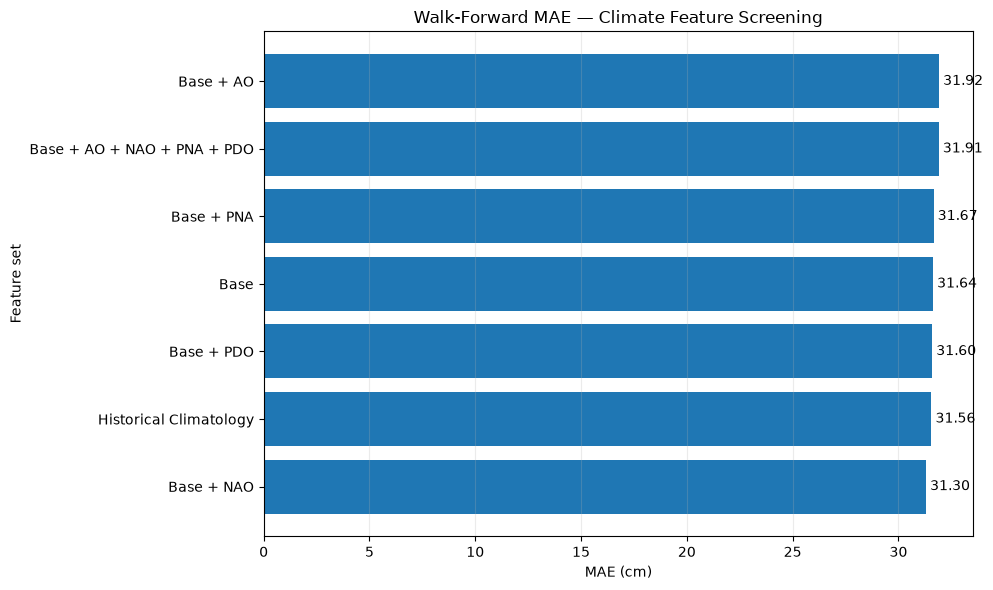

In [17]:

plot_comp = comparison.sort_values(
    "MAE_cm",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_comp["feature_set"],
    plot_comp["MAE_cm"]
)

ax.set_title(
    "Walk-Forward MAE — Climate Feature Screening"
)
ax.set_xlabel("MAE (cm)")
ax.set_ylabel("Feature set")
ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(
    plot_comp["MAE_cm"]
):
    ax.text(
        value,
        i,
        f" {value:.2f}",
        va="center"
    )

fig.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "part_b_feature_screening_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 15. Inspect the best feature-set forecasts

In [18]:

ml_comparison = comparison[
    comparison["feature_set"]
    != "Historical Climatology"
].copy()

BEST_FEATURE_SET = (
    ml_comparison.iloc[0]["feature_set"]
)

print(
    "Best ElasticNet feature set:",
    BEST_FEATURE_SET
)

best_preds = screen_predictions[
    screen_predictions["feature_set"]
    == BEST_FEATURE_SET
].copy()

display(
    best_preds.nlargest(
        10,
        "abs_error_cm"
    )[
        [
            "season_year",
            "actual_cm",
            "predicted_cm",
            "error_cm",
            "abs_error_cm"
        ]
    ]
)


Best ElasticNet feature set: Base + NAO


,season_year,actual_cm,predicted_cm,error_cm,abs_error_cm
269,2012,42.8,119.272549,76.472549,76.472549
241,2008,194.0,119.527813,-74.472187,74.472187
346,2026,190.6,116.407856,-74.192144,74.192144
255,2010,52.4,122.275000,69.875000,69.875000
66,1980,79.7,145.814810,66.114810,66.114810
87,1983,71.5,136.934704,65.434704,65.434704
234,2007,60.3,121.516981,61.216981,61.216981
129,1989,72.2,127.599622,55.399622,55.399622
10,1972,188.9,133.849657,-55.050343,55.050343
73,1981,81.8,132.777352,50.977352,50.977352


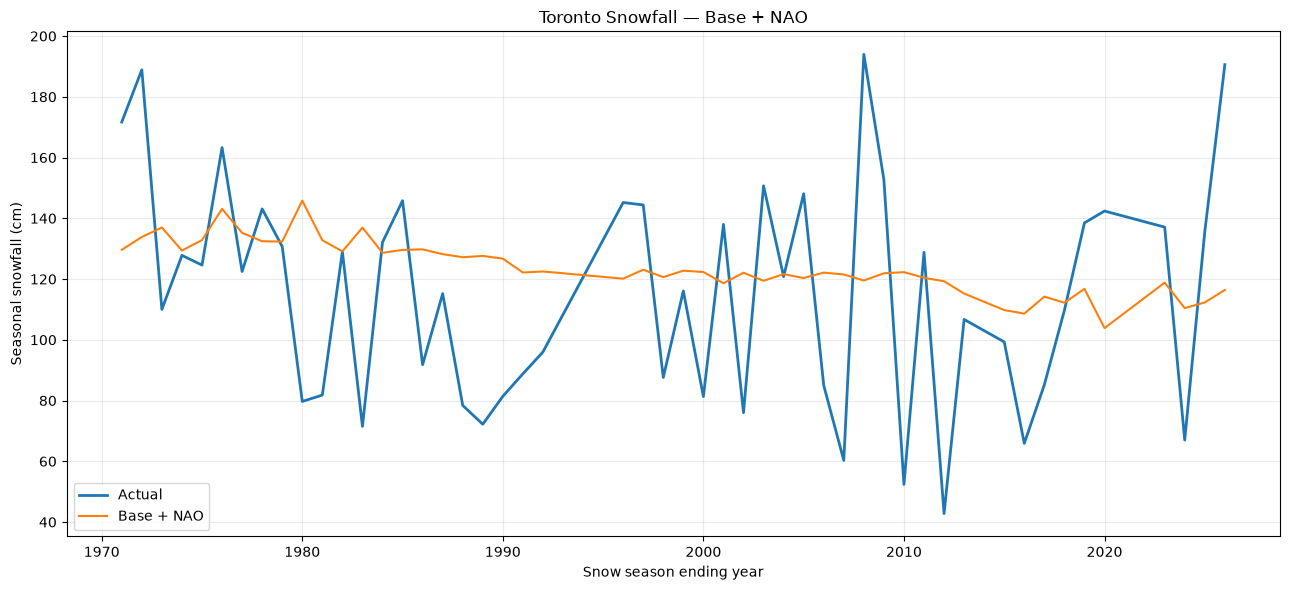

In [19]:

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    best_preds["season_year"],
    best_preds["actual_cm"],
    linewidth=2,
    label="Actual"
)

ax.plot(
    best_preds["season_year"],
    best_preds["predicted_cm"],
    linewidth=1.5,
    label=BEST_FEATURE_SET
)

ax.set_title(
    f"Toronto Snowfall — {BEST_FEATURE_SET}"
)
ax.set_xlabel("Snow season ending year")
ax.set_ylabel("Seasonal snowfall (cm)")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "part_b_best_improved_feature_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 16. Save feature-screening outputs

In [20]:

ENHANCED_PATH = (
    PROCESSED_DIR
    / "forecast_modeling_dataset_enhanced.csv"
)

SCREEN_PRED_PATH = (
    PROCESSED_DIR
    / "feature_screening_walk_forward_predictions.csv"
)

SCREEN_COMPARE_PATH = (
    PROCESSED_DIR
    / "feature_screening_comparison.csv"
)

enhanced.to_csv(
    ENHANCED_PATH,
    index=False
)

screen_predictions.to_csv(
    SCREEN_PRED_PATH,
    index=False
)

comparison.to_csv(
    SCREEN_COMPARE_PATH,
    index=False
)

print("Saved:")
print(ENHANCED_PATH)
print(SCREEN_PRED_PATH)
print(SCREEN_COMPARE_PATH)


Saved:
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/forecast_modeling_dataset_enhanced.csv
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/feature_screening_walk_forward_predictions.csv
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/feature_screening_comparison.csv


## 17. Generate screening report

In [21]:

best_row = comparison.iloc[0]

report = [
    "# Toronto Snowfall Forecast — Climate Feature Screening",
    "",
    f"- Common modeling winters: {len(analysis_data)}",
    f"- Common range: {int(analysis_data['season_year'].min())}–{int(analysis_data['season_year'].max())}",
    f"- First walk-forward test winter: {FIRST_TEST_SEASON}",
    f"- Out-of-sample winters: {len(analysis_data) - MIN_TRAIN_SIZE}",
    "",
    "## Full-period results",
    "",
]

for _, row in comparison.iterrows():
    report.append(
        f"- {row['feature_set']}: "
        f"MAE={row['MAE_cm']:.2f} cm, "
        f"RMSE={row['RMSE_cm']:.2f} cm, "
        f"bias={row['Bias_cm']:+.2f} cm, "
        f"skill vs climatology={row['skill_vs_climatology_pct']:+.1f}%"
    )

report.extend([
    "",
    "## Best full-period method",
    "",
    f"**{best_row['feature_set']}**",
    "",
    "These results are exploratory feature screening. "
    "Because several candidate climate indices were tested on a small dataset, "
    "the best result should be treated as a candidate for confirmation rather "
    "than proof of stable predictive skill.",
])

REPORT_PATH = (
    REPORTS_DIR
    / "part_b_feature_screening_report.md"
)

REPORT_PATH.write_text(
    "\n".join(report),
    encoding="utf-8"
)

print(REPORT_PATH.read_text())


# Toronto Snowfall Forecast — Climate Feature Screening

- Common modeling winters: 70
- Common range: 1951–2026
- First walk-forward test winter: 1971
- Out-of-sample winters: 50

## Full-period results

- Base + NAO: MAE=31.30 cm, RMSE=38.05 cm, bias=+8.82 cm, skill vs climatology=+0.8%
- Historical Climatology: MAE=31.56 cm, RMSE=37.87 cm, bias=+9.92 cm, skill vs climatology=+0.0%
- Base + PDO: MAE=31.60 cm, RMSE=37.93 cm, bias=+8.92 cm, skill vs climatology=-0.1%
- Base: MAE=31.64 cm, RMSE=37.97 cm, bias=+8.84 cm, skill vs climatology=-0.2%
- Base + PNA: MAE=31.67 cm, RMSE=37.95 cm, bias=+8.99 cm, skill vs climatology=-0.3%
- Base + AO + NAO + PNA + PDO: MAE=31.91 cm, RMSE=38.44 cm, bias=+9.20 cm, skill vs climatology=-1.1%
- Base + AO: MAE=31.92 cm, RMSE=38.17 cm, bias=+9.20 cm, skill vs climatology=-1.1%

## Best full-period method

**Base + NAO**

These results are exploratory feature screening. Because several candidate climate indices were tested on a small dataset, the best r


# Decision after this notebook

Send these three outputs for review:

1. **correlation-with-snowfall table**
2. **full walk-forward feature comparison**
3. **recent-period comparison**

## If one or more new features consistently improve the base model

We will keep only the useful signals and rerun the main model comparison:

- climatology
- rolling climatology
- ElasticNet
- CatBoost

using the improved feature set.

## If none improve out-of-sample skill

We should **not keep adding random indices**.

The next scientifically useful direction would be a different class of predictor, such as:

- seasonal dynamical-model temperature/precipitation forecasts,
- Great Lakes / regional thermal conditions,
- snow-cover or sea-ice precursor variables,
- a different forecast issuance date.

The goal is predictive skill, not feature count.
